In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/cshasha/breast-cancer/refs/heads/master/dataR2.csv')

In [19]:
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [20]:
df.shape

(116, 10)

In [21]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [24]:
model.score(X_test, y_test)

0.875

### Sequential Backward Selection

In [25]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
sfs = SFS(
    estimator=model,
    k_features=3,  # Number of features to select
    forward=False,  # Backward selection
    floating=False,  # Floating selection
    scoring='accuracy',
    cv=cv
)

In [27]:
sfs.fit(X_train, y_train)

SequentialFeatureSelector(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                          estimator=LogisticRegression(max_iter=5000),
                          forward=False, k_features=(3, 3), scoring='accuracy')

In [28]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt


In [29]:
# Chosen feature names
print(sfs.k_feature_names_)

('BMI', 'Glucose', 'Insulin')


In [30]:
# Accuracy of the model after fwd selection
print(sfs.k_score_)

0.7046783625730995


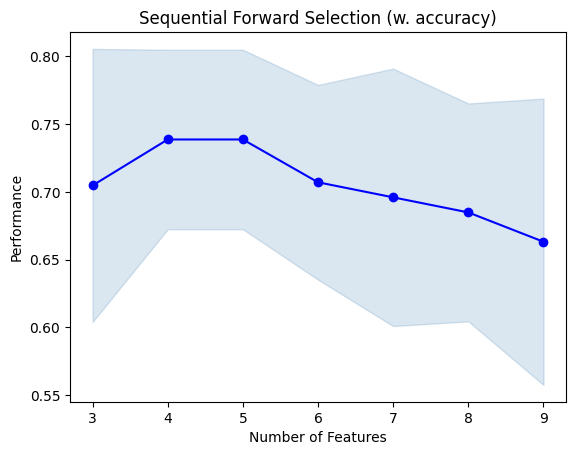

In [31]:
# Plot the model accuracy
plot_sfs(sfs.get_metric_dict())
plt.title('Sequential Forward Selection (w. accuracy)')
plt.show()

In [32]:
# indices of selected features
selected_idx = list(sfs.k_feature_idx_)

# reduce train and test to selected features
X_train_sfs = X_train.iloc[:, selected_idx]
X_test_sfs  = X_test.iloc[:, selected_idx]

# retrain model on selected features
model_sfs = LogisticRegression(max_iter=5000)
model_sfs.fit(X_train_sfs, y_train)

# test accuracy on real test set
test_acc_sfs = model_sfs.score(X_test_sfs, y_test)
print("Test accuracy with selected features:", test_acc_sfs)


Test accuracy with selected features: 0.8333333333333334
